In [9]:
!ls -lh /content

total 159M
-rw-r--r-- 1 root root 159M Jul  2 14:20 combined_data_1.txt.zip
-rw-r--r-- 1 root root 565K Jul  2 14:18 movie_titles.csv
drwxr-xr-x 2 root root 4.0K Jul  2 14:17 netflix_data
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data


In [10]:
!mkdir -p /content/netflix_data
!unzip -q /content/combined_data_1.txt.zip -d /content/netflix_data
!ls -lh /content/netflix_data

total 473M
-rw-r--r-- 1 root root 473M Nov 13  2019 combined_data_1.txt


In [11]:
!file /content/combined_data_1.txt.zip
!head -n 5 /content/combined_data_1.txt.zip
!ls -lh /content/combined_data_1.txt.zip

/content/combined_data_1.txt.zip: Zip archive data, at least v4.5 to extract, compression method=deflate
PK-    �mOT�����������  combined_data_1.txt  Ȗ�    U��	    l}Y�,9����3�C�a� �"����*,3�]� � �����Z�����WR�������*%���|�����VO��_��r���_Mk��Q�W�����W���{��+r���_.-��k?��G��J%~��+�/�VrY�'��ԕF�O����{�k��y�!~2�9�}���+}�4���e�WZ+�չ��V����e�3�����b/�ږφ�_Nk�4���ӱߞ9�������^�~Oh�c�~;��	;����h�d���Fm�w��W��)��@x�?���{��X�%;�Rf-�?���r�~��͔�1�e�k�Y��D�c�5�������Zgo�<�iO��yC&������l�	J��H|�vo"��j/�����j/��������l���xp�eT;J�ȒL&
���׺x�5)L���b���,9tf�|Z��������e���4*f��gER�&��C�Y�f��j�Y�dǖ��$wUü@o��I�7j2{,����l�~Ϥ�ju۩gy\�ܻ�-U�i�-��̖��A���x��ۆrٙ��؇5�gu?��ڷ\޺��YH���7JK����";����&�<��ꛘ&�\?+�>�����q�pϥϽD �'��뎣��m�
IY��r���
fz,������iV|��T 䢗0e��Z>/
��[QY��:��C��_����h��������U��<��<�
-rw-r--r-- 1 root root 159M Jul  2 14:20 /content/combined_data_1.txt.zip


In [12]:
!unzip -t /content/combined_data_1.txt.zip

Archive:  /content/combined_data_1.txt.zip
    testing: combined_data_1.txt      OK
No errors detected in compressed data of /content/combined_data_1.txt.zip.


In [13]:
!rm -rf /content/netflix_data
!mkdir -p /content/netflix_data
!unzip -q /content/combined_data_1.txt.zip -d /content/netflix_data
!ls -lh /content/netflix_data

total 473M
-rw-r--r-- 1 root root 473M Nov 13  2019 combined_data_1.txt


In [14]:
ratings_path = "/content/netflix_data/combined_data_1.txt"
titles_path = "/content/movie_titles.csv"

In [15]:
import pandas as pd
import numpy as np
import random
from collections import defaultdict

def parse_netflix_file(path, max_rows=None):
    rows = []
    movie_id = None

    with open(path, "r", encoding="latin1") as f:
        for line in f:
            line = line.strip()

            if line.endswith(":"):
                movie_id = int(line[:-1])
            else:
                user_id, rating, date = line.split(",")
                rows.append((int(user_id), movie_id, int(rating), date))

                if max_rows is not None and len(rows) >= max_rows:
                    break

    return pd.DataFrame(rows, columns=["user_id", "movie_id", "rating", "date"])

# New Section

In [16]:
df = parse_netflix_file(ratings_path, max_rows=1_000_000)

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M").astype(str)

df["preference"] = np.where(
    df["rating"] >= 4, "liked",
    np.where(df["rating"] <= 2, "disliked", "neutral")
)

print("ratings:", len(df))
print("users:", df["user_id"].nunique())
print("movies:", df["movie_id"].nunique())

df.head()

ratings: 1000000
users: 283705
movies: 225


,user_id,movie_id,rating,date,month,preference
0,1488844,1,3,2005-09-06,2005-09,neutral
1,822109,1,5,2005-05-13,2005-05,liked
2,885013,1,4,2005-10-19,2005-10,liked
3,30878,1,4,2005-12-26,2005-12,liked
4,823519,1,3,2004-05-03,2004-05,neutral


In [17]:
modes_to_cols = {
    "movie_only": ["movie_id"],
    "movie_rating": ["movie_id", "rating"],
    "movie_preference": ["movie_id", "preference"],
    "movie_month": ["movie_id", "month"],
    "movie_rating_month": ["movie_id", "rating", "month"],
}

In [18]:
def make_key_from_row(row, cols):
    values = tuple(row[c] for c in cols)
    return values[0] if len(values) == 1 else values


def build_index(df, cols):
    # Drop duplicates so a user only appears once per fact
    small = df[cols + ["user_id"]].drop_duplicates()

    # groupby returns scalar keys for one column, tuple keys for multiple columns
    index = small.groupby(cols)["user_id"].agg(lambda x: set(x)).to_dict()
    return index

In [19]:
indexes = {}

for mode, cols in modes_to_cols.items():
    print("building:", mode)
    indexes[mode] = build_index(df, cols)

print("done")

building: movie_only
building: movie_rating
building: movie_preference
building: movie_month
building: movie_rating_month
done


In [20]:
user_histories = {
    user_id: group
    for user_id, group in df.groupby("user_id")
}

In [21]:
def candidate_count(known_rows, mode):
    cols = modes_to_cols[mode]
    index = indexes[mode]

    candidates = None

    for _, row in known_rows.iterrows():
        key = make_key_from_row(row, cols)
        matching_users = index.get(key, set())

        if candidates is None:
            candidates = set(matching_users)
        else:
            candidates &= matching_users

    return len(candidates)

In [22]:
eligible_users = [u for u, hist in user_histories.items() if len(hist) >= 2]

target_user = random.choice(eligible_users)
known_rows = user_histories[target_user].sample(2, random_state=0)

print("Target user:", target_user)
display(known_rows)

for mode in modes_to_cols:
    print(mode, "candidate count:", candidate_count(known_rows, mode))

Target user: 532798


,user_id,movie_id,rating,date,month,preference
764063,532798,191,5,2004-02-25,2004-02,liked
71543,532798,28,3,2004-02-25,2004-02,neutral


movie_only candidate count: 22861
movie_rating candidate count: 1329
movie_preference candidate count: 3980
movie_month candidate count: 188
movie_rating_month candidate count: 8


In [23]:
def run_experiment(n_known_values=[1, 2, 3], trials_per_setting=200):
    results = []

    user_counts = df["user_id"].value_counts()

    for n_known in n_known_values:
        eligible_users = user_counts[user_counts >= n_known].index.tolist()

        for mode in modes_to_cols:
            print(f"Running mode={mode}, n_known={n_known}")

            for _ in range(trials_per_setting):
                target_user = random.choice(eligible_users)
                history = user_histories[target_user]

                known_rows = history.sample(n_known)
                k = candidate_count(known_rows, mode)

                results.append({
                    "mode": mode,
                    "n_known": n_known,
                    "target_user": target_user,
                    "candidate_count": k
                })

    return pd.DataFrame(results)

In [24]:
results = run_experiment(
    n_known_values=[1, 2, 3],
    trials_per_setting=200
)

results.head(15)

Running mode=movie_only, n_known=1
Running mode=movie_rating, n_known=1
Running mode=movie_preference, n_known=1
Running mode=movie_month, n_known=1
Running mode=movie_rating_month, n_known=1
Running mode=movie_only, n_known=2
Running mode=movie_rating, n_known=2
Running mode=movie_preference, n_known=2
Running mode=movie_month, n_known=2
Running mode=movie_rating_month, n_known=2
Running mode=movie_only, n_known=3
Running mode=movie_rating, n_known=3
Running mode=movie_preference, n_known=3
Running mode=movie_month, n_known=3
Running mode=movie_rating_month, n_known=3


,mode,n_known,target_user,candidate_count
0,movie_only,1,1213155,118413
1,movie_only,1,2200917,38362
2,movie_only,1,852261,118413
3,movie_only,1,129546,39752
4,movie_only,1,2183914,13598
5,movie_only,1,1052015,35509
6,movie_only,1,956514,9151
7,movie_only,1,1623526,118413
8,movie_only,1,2150292,81260
9,movie_only,1,1943161,10722


In [25]:
summary = results.groupby(["mode", "n_known"]).agg(
    avg_candidate_size=("candidate_count", "mean"),
    median_candidate_size=("candidate_count", "median"),
    pct_unique=("candidate_count", lambda x: (x == 1).mean() * 100),
    pct_5_or_less=("candidate_count", lambda x: (x <= 5).mean() * 100),
    pct_10_or_less=("candidate_count", lambda x: (x <= 10).mean() * 100),
).reset_index()

summary

,mode,n_known,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,pct_10_or_less
0,movie_month,1,2992.670,1766.5,0.0,0.5,1.0
1,movie_month,2,88.615,20.5,15.5,31.0,39.5
2,movie_month,3,11.895,1.0,58.5,82.5,88.0
3,movie_only,1,53309.885,38362.0,0.0,0.0,0.0
4,movie_only,2,10934.410,4896.5,0.0,0.0,0.0
5,movie_only,3,3609.785,1530.5,0.5,0.5,1.0
6,movie_preference,1,31139.530,24749.0,0.0,0.0,0.0
7,movie_preference,2,3316.465,1157.5,0.5,2.5,4.5
8,movie_preference,3,561.555,135.5,5.5,13.5,20.5
9,movie_rating,1,17756.555,12697.0,0.0,0.0,0.0


In [26]:
modes_to_cols = {
    "movie_only": ["movie_id"],
    "movie_rating": ["movie_id", "rating"],
    "movie_preference": ["movie_id", "preference"],
    "movie_month": ["movie_id", "month"],
    "movie_rating_month": ["movie_id", "rating", "month"],
    "movie_date": ["movie_id", "date"],
    "movie_rating_date": ["movie_id", "rating", "date"],
}

In [27]:
indexes = {}

for mode, cols in modes_to_cols.items():
    print("building:", mode)
    indexes[mode] = build_index(df, cols)

print("done")

building: movie_only
building: movie_rating
building: movie_preference
building: movie_month
building: movie_rating_month
building: movie_date
building: movie_rating_date
done


In [28]:
movie_popularity = df.groupby("movie_id")["user_id"].nunique().rename("movie_popularity")
movie_info = movie_popularity.reset_index()

movie_info["popularity_bucket"] = pd.qcut(
    movie_info["movie_popularity"].rank(method="first"),
    q=4,
    labels=["rare", "less_common", "common", "popular"]
)

df = df.merge(movie_info, on="movie_id", how="left")
df.head()

,user_id,movie_id,rating,date,month,preference,movie_popularity,popularity_bucket
0,1488844,1,3,2005-09-06,2005-09,neutral,547,common
1,822109,1,5,2005-05-13,2005-05,liked,547,common
2,885013,1,4,2005-10-19,2005-10,liked,547,common
3,30878,1,4,2005-12-26,2005-12,liked,547,common
4,823519,1,3,2004-05-03,2004-05,neutral,547,common


In [29]:
user_histories = {
    user_id: group
    for user_id, group in df.groupby("user_id")
}

In [30]:
def run_experiment_with_features(n_known_values=[1, 2, 3], trials_per_setting=200):
    results = []

    user_counts = df["user_id"].value_counts()

    for n_known in n_known_values:
        eligible_users = user_counts[user_counts >= n_known].index.tolist()

        for mode in modes_to_cols:
            print(f"Running mode={mode}, n_known={n_known}")

            for _ in range(trials_per_setting):
                target_user = random.choice(eligible_users)
                history = user_histories[target_user]

                known_rows = history.sample(n_known)
                k = candidate_count(known_rows, mode)

                rarest_row = known_rows.sort_values("movie_popularity").iloc[0]

                results.append({
                    "mode": mode,
                    "n_known": n_known,
                    "target_user": target_user,
                    "candidate_count": k,

                    "avg_movie_popularity": known_rows["movie_popularity"].mean(),
                    "min_movie_popularity": known_rows["movie_popularity"].min(),
                    "rarest_movie_bucket": rarest_row["popularity_bucket"],

                    "avg_rating": known_rows["rating"].mean(),
                    "min_rating": known_rows["rating"].min(),
                    "max_rating": known_rows["rating"].max(),
                    "has_low_rating": (known_rows["rating"] <= 2).any(),
                    "has_high_rating": (known_rows["rating"] >= 4).any(),
                })

    return pd.DataFrame(results)

In [31]:
results2 = run_experiment_with_features(
    n_known_values=[1, 2, 3],
    trials_per_setting=300
)

results2.head()

Running mode=movie_only, n_known=1
Running mode=movie_rating, n_known=1
Running mode=movie_preference, n_known=1
Running mode=movie_month, n_known=1
Running mode=movie_rating_month, n_known=1
Running mode=movie_date, n_known=1
Running mode=movie_rating_date, n_known=1
Running mode=movie_only, n_known=2
Running mode=movie_rating, n_known=2
Running mode=movie_preference, n_known=2
Running mode=movie_month, n_known=2
Running mode=movie_rating_month, n_known=2
Running mode=movie_date, n_known=2
Running mode=movie_rating_date, n_known=2
Running mode=movie_only, n_known=3
Running mode=movie_rating, n_known=3
Running mode=movie_preference, n_known=3
Running mode=movie_month, n_known=3
Running mode=movie_rating_month, n_known=3
Running mode=movie_date, n_known=3
Running mode=movie_rating_date, n_known=3


,mode,n_known,target_user,candidate_count,avg_movie_popularity,min_movie_popularity,rarest_movie_bucket,avg_rating,min_rating,max_rating,has_low_rating,has_high_rating
0,movie_only,1,1269038,5147,5147.0,5147,popular,5.0,5,5,False,True
1,movie_only,1,420812,6558,6558.0,6558,popular,3.0,3,3,False,False
2,movie_only,1,865804,118413,118413.0,118413,popular,3.0,3,3,False,False
3,movie_only,1,903089,98720,98720.0,98720,popular,3.0,3,3,False,False
4,movie_only,1,2360897,118413,118413.0,118413,popular,4.0,4,4,False,True


In [32]:
rare_summary = (
    results2[results2["mode"] == "movie_rating_month"]
    .groupby(["n_known", "rarest_movie_bucket"])
    .agg(
        avg_candidate_size=("candidate_count", "mean"),
        median_candidate_size=("candidate_count", "median"),
        pct_unique=("candidate_count", lambda x: (x == 1).mean() * 100),
        pct_5_or_less=("candidate_count", lambda x: (x <= 5).mean() * 100),
        count=("candidate_count", "size"),
    )
    .reset_index()
)

rare_summary

,n_known,rarest_movie_bucket,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,count
0,1,common,19.466667,17.0,0.000000,6.666667,15
1,1,less_common,9.666667,6.0,0.000000,33.333333,3
2,1,popular,911.726950,556.0,0.000000,0.709220,282
3,2,common,1.192308,1.0,84.615385,100.000000,26
4,2,less_common,1.000000,1.0,100.000000,100.000000,3
5,2,popular,12.456929,3.0,32.958801,61.797753,267
6,2,rare,1.000000,1.0,100.000000,100.000000,4
7,3,common,1.000000,1.0,100.000000,100.000000,31
8,3,less_common,1.000000,1.0,100.000000,100.000000,14
9,3,popular,1.295547,1.0,89.473684,98.380567,247


In [33]:
low_rating_summary = (
    results2[results2["mode"] == "movie_rating_month"]
    .groupby(["n_known", "has_low_rating"])
    .agg(
        avg_candidate_size=("candidate_count", "mean"),
        median_candidate_size=("candidate_count", "median"),
        pct_unique=("candidate_count", lambda x: (x == 1).mean() * 100),
        pct_5_or_less=("candidate_count", lambda x: (x <= 5).mean() * 100),
        count=("candidate_count", "size"),
    )
    .reset_index()
)

low_rating_summary

,n_known,has_low_rating,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,count
0,1,False,964.149425,650.0,0.000000,1.149425,261
1,1,True,148.333333,98.0,0.000000,2.564103,39
2,2,False,13.809735,3.0,32.743363,61.061947,226
3,2,True,3.283784,1.0,58.108108,81.081081,74
4,3,False,1.343137,1.0,88.725490,98.039216,204
5,3,True,1.031250,1.0,96.875000,100.000000,96


In [34]:
high_rating_summary = (
    results2[results2["mode"] == "movie_rating_month"]
    .groupby(["n_known", "has_high_rating"])
    .agg(
        avg_candidate_size=("candidate_count", "mean"),
        median_candidate_size=("candidate_count", "median"),
        pct_unique=("candidate_count", lambda x: (x == 1).mean() * 100),
        pct_5_or_less=("candidate_count", lambda x: (x <= 5).mean() * 100),
        count=("candidate_count", "size"),
    )
    .reset_index()
)

high_rating_summary

,n_known,has_high_rating,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,count
0,1,False,557.663866,245.0,0.000000,1.680672,119
1,1,True,1055.613260,742.0,0.000000,1.104972,181
2,2,False,6.158730,2.0,49.206349,73.015873,63
3,2,True,12.556962,3.0,36.286920,64.135021,237
4,3,False,1.000000,1.0,100.000000,100.000000,33
5,3,True,1.273408,1.0,90.262172,98.501873,267


In [35]:
baseline_summary = summary.copy()
baseline_summary["dataset_version"] = "original_non_anonymized"

baseline_summary

,mode,n_known,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,pct_10_or_less,dataset_version
0,movie_month,1,2992.670,1766.5,0.0,0.5,1.0,original_non_anonymized
1,movie_month,2,88.615,20.5,15.5,31.0,39.5,original_non_anonymized
2,movie_month,3,11.895,1.0,58.5,82.5,88.0,original_non_anonymized
3,movie_only,1,53309.885,38362.0,0.0,0.0,0.0,original_non_anonymized
4,movie_only,2,10934.410,4896.5,0.0,0.0,0.0,original_non_anonymized
5,movie_only,3,3609.785,1530.5,0.5,0.5,1.0,original_non_anonymized
6,movie_preference,1,31139.530,24749.0,0.0,0.0,0.0,original_non_anonymized
7,movie_preference,2,3316.465,1157.5,0.5,2.5,4.5,original_non_anonymized
8,movie_preference,3,561.555,135.5,5.5,13.5,20.5,original_non_anonymized
9,movie_rating,1,17756.555,12697.0,0.0,0.0,0.0,original_non_anonymized


In [36]:
baseline_summary.to_csv("baseline_non_anonymized_summary.csv", index=False)

In [37]:
from google.colab import files
files.download("baseline_non_anonymized_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
import pandas as pd
import numpy as np
import random

In [39]:
def make_releases(df):
    releases = []

    # Original-ish release
    releases.append({
        "name": "original_movie_rating_month",
        "data": df.copy(),
        "cols": ["movie_id", "rating", "month"]
    })

    # Defense 1: remove month
    releases.append({
        "name": "remove_month",
        "data": df.copy(),
        "cols": ["movie_id", "rating"]
    })

    # Defense 2: coarsen rating
    releases.append({
        "name": "coarsen_rating_to_preference",
        "data": df.copy(),
        "cols": ["movie_id", "preference", "month"]
    })

    # Defense 3: remove month and coarsen rating
    releases.append({
        "name": "remove_month_and_coarsen_rating",
        "data": df.copy(),
        "cols": ["movie_id", "preference"]
    })

    # Defense 4: movie only
    releases.append({
        "name": "movie_only",
        "data": df.copy(),
        "cols": ["movie_id"]
    })

    # Defense 5: remove rare movies
    movie_counts = df.groupby("movie_id")["user_id"].nunique()
    common_movies = movie_counts[movie_counts >= 500].index

    df_no_rare = df[df["movie_id"].isin(common_movies)].copy()

    releases.append({
        "name": "remove_rare_movies_min_500_users",
        "data": df_no_rare,
        "cols": ["movie_id", "rating", "month"]
    })

    return releases

In [40]:
def build_index_for_cols(data, cols):
    small = data[cols + ["user_id"]].drop_duplicates()
    return small.groupby(cols)["user_id"].agg(lambda x: set(x)).to_dict()


def row_key(row, cols):
    values = tuple(row[c] for c in cols)
    return values[0] if len(values) == 1 else values


def candidate_count_for_rows(known_rows, cols, index):
    candidates = None

    for _, row in known_rows.iterrows():
        key = row_key(row, cols)
        matching = index.get(key, set())

        if candidates is None:
            candidates = set(matching)
        else:
            candidates &= matching

    return len(candidates)


def evaluate_release(data, release_name, cols, n_known_values=[1, 2, 3], trials=300):
    index = build_index_for_cols(data, cols)

    user_histories = {
        user_id: group
        for user_id, group in data.groupby("user_id")
    }

    user_counts = data["user_id"].value_counts()
    results = []

    for n_known in n_known_values:
        eligible_users = user_counts[user_counts >= n_known].index.tolist()

        for _ in range(trials):
            target_user = random.choice(eligible_users)
            history = user_histories[target_user]

            known_rows = history.sample(n_known)
            k = candidate_count_for_rows(known_rows, cols, index)

            results.append({
                "release_name": release_name,
                "knowledge_cols": " + ".join(cols),
                "n_known": n_known,
                "target_user": target_user,
                "candidate_count": k,
                "unique": k == 1,
                "surety_pct": 100 / k if k > 0 else 0,
            })

    return pd.DataFrame(results)

In [41]:
releases = make_releases(df)

all_results = []

for release in releases:
    print("Evaluating:", release["name"])
    result = evaluate_release(
        data=release["data"],
        release_name=release["name"],
        cols=release["cols"],
        n_known_values=[1, 2, 3],
        trials=300
    )
    all_results.append(result)

all_results = pd.concat(all_results, ignore_index=True)

all_results.head(15)

Evaluating: original_movie_rating_month
Evaluating: remove_month
Evaluating: coarsen_rating_to_preference
Evaluating: remove_month_and_coarsen_rating
Evaluating: movie_only
Evaluating: remove_rare_movies_min_500_users


,release_name,knowledge_cols,n_known,target_user,candidate_count,unique,surety_pct
0,original_movie_rating_month,movie_id + rating + month,1,105825,122,False,0.819672
1,original_movie_rating_month,movie_id + rating + month,1,1503658,1321,False,0.075700
2,original_movie_rating_month,movie_id + rating + month,1,1771105,37,False,2.702703
3,original_movie_rating_month,movie_id + rating + month,1,2210464,1366,False,0.073206
4,original_movie_rating_month,movie_id + rating + month,1,2209827,1312,False,0.076220
5,original_movie_rating_month,movie_id + rating + month,1,2568730,284,False,0.352113
6,original_movie_rating_month,movie_id + rating + month,1,2539103,2057,False,0.048614
7,original_movie_rating_month,movie_id + rating + month,1,1970358,1546,False,0.064683
8,original_movie_rating_month,movie_id + rating + month,1,2404171,2199,False,0.045475
9,original_movie_rating_month,movie_id + rating + month,1,876063,1057,False,0.094607


In [42]:
evaluation_summary = all_results.groupby(
    ["release_name", "knowledge_cols", "n_known"]
).agg(
    avg_candidate_size=("candidate_count", "mean"),
    median_candidate_size=("candidate_count", "median"),
    pct_unique=("unique", lambda x: x.mean() * 100),
    pct_5_or_less=("candidate_count", lambda x: (x <= 5).mean() * 100),
    pct_10_or_less=("candidate_count", lambda x: (x <= 10).mean() * 100),
    avg_surety_pct=("surety_pct", "mean"),
    median_surety_pct=("surety_pct", "median"),
).reset_index()

evaluation_summary

,release_name,knowledge_cols,n_known,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,pct_10_or_less,avg_surety_pct,median_surety_pct
0,coarsen_rating_to_preference,movie_id + preference + month,1,1422.276667,714.0,0.333333,2.666667,4.000000,1.942621,0.140060
1,coarsen_rating_to_preference,movie_id + preference + month,2,25.913333,4.0,29.333333,54.333333,67.333333,41.724018,25.000000
2,coarsen_rating_to_preference,movie_id + preference + month,3,1.896667,1.0,83.666667,96.000000,97.333333,88.998120,100.000000
3,movie_only,movie_id,1,57901.563333,39752.0,0.000000,0.000000,0.000000,0.017121,0.002516
4,movie_only,movie_id,2,13673.870000,6348.0,0.000000,0.666667,0.666667,0.465982,0.015753
5,movie_only,movie_id,3,4300.996667,1984.5,0.000000,0.000000,1.333333,0.668334,0.050391
6,original_movie_rating_month,movie_id + rating + month,1,829.913333,452.0,0.666667,3.000000,7.000000,2.592780,0.221240
7,original_movie_rating_month,movie_id + rating + month,2,11.856667,2.0,41.000000,70.333333,79.333333,53.918747,50.000000
8,original_movie_rating_month,movie_id + rating + month,3,1.320000,1.0,90.000000,97.666667,99.000000,93.561255,100.000000
9,remove_month,movie_id + rating,1,16586.916667,10856.0,0.000000,0.000000,0.000000,0.100213,0.009211


In [43]:
plot_df = evaluation_summary.copy()

pretty_names = {
    "original_movie_rating_month": "Original: movie + rating + month",
    "remove_month": "Remove month",
    "coarsen_rating_to_preference": "Coarsen rating",
    "remove_month_and_coarsen_rating": "Remove month + coarsen rating",
    "movie_only": "Movie only",
    "remove_rare_movies_min_500_users": "Remove rare movies",
}

plot_df["release_label"] = plot_df["release_name"].map(pretty_names)

release_order = [
    "Original: movie + rating + month",
    "Remove month",
    "Coarsen rating",
    "Remove month + coarsen rating",
    "Movie only",
    "Remove rare movies",
]

plot_df["release_label"] = pd.Categorical(
    plot_df["release_label"],
    categories=release_order,
    ordered=True
)

plot_df = plot_df.sort_values(["n_known", "release_label"])
plot_df.head()

,release_name,knowledge_cols,n_known,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,pct_10_or_less,avg_surety_pct,median_surety_pct,release_label
6,original_movie_rating_month,movie_id + rating + month,1,829.913333,452.0,0.666667,3.000000,7.0,2.592780,0.221240,Original: movie + rating + month
9,remove_month,movie_id + rating,1,16586.916667,10856.0,0.000000,0.000000,0.0,0.100213,0.009211,Remove month
0,coarsen_rating_to_preference,movie_id + preference + month,1,1422.276667,714.0,0.333333,2.666667,4.0,1.942621,0.140060,Coarsen rating
12,remove_month_and_coarsen_rating,movie_id + preference,1,29953.783333,24749.0,0.000000,0.000000,0.0,0.061011,0.004041,Remove month + coarsen rating
3,movie_only,movie_id,1,57901.563333,39752.0,0.000000,0.000000,0.0,0.017121,0.002516,Movie only


In [44]:
table3 = plot_df[plot_df["n_known"] == 3][[
    "release_label",
    "knowledge_cols",
    "median_candidate_size",
    "avg_candidate_size",
    "pct_unique",
    "pct_5_or_less",
    "pct_10_or_less",
    "avg_surety_pct"
]].copy()

table3 = table3.rename(columns={
    "release_label": "Released data version",
    "knowledge_cols": "Attacker knowledge",
    "median_candidate_size": "Median candidate size",
    "avg_candidate_size": "Average candidate size",
    "pct_unique": "% uniquely identified",
    "pct_5_or_less": "% ≤ 5 candidates",
    "pct_10_or_less": "% ≤ 10 candidates",
    "avg_surety_pct": "Average surety %"
})

table3.style.format({
    "Median candidate size": "{:.1f}",
    "Average candidate size": "{:.1f}",
    "% uniquely identified": "{:.1f}%",
    "% ≤ 5 candidates": "{:.1f}%",
    "% ≤ 10 candidates": "{:.1f}%",
    "Average surety %": "{:.1f}%"
})

,Released data version,Attacker knowledge,Median candidate size,Average candidate size,% uniquely identified,% ≤ 5 candidates,% ≤ 10 candidates,Average surety %
8,Original: movie + rating + month,movie_id + rating + month,1.0,1.3,90.0%,97.7%,99.0%,93.6%
11,Remove month,movie_id + rating,37.5,125.8,7.7%,18.3%,28.0%,14.5%
2,Coarsen rating,movie_id + preference + month,1.0,1.9,83.7%,96.0%,97.3%,89.0%
14,Remove month + coarsen rating,movie_id + preference,169.0,687.6,4.3%,13.0%,17.0%,9.0%
5,Movie only,movie_id,1984.5,4301.0,0.0%,0.0%,1.3%,0.7%
17,Remove rare movies,movie_id + rating + month,1.0,1.4,86.3%,96.7%,99.0%,91.2%


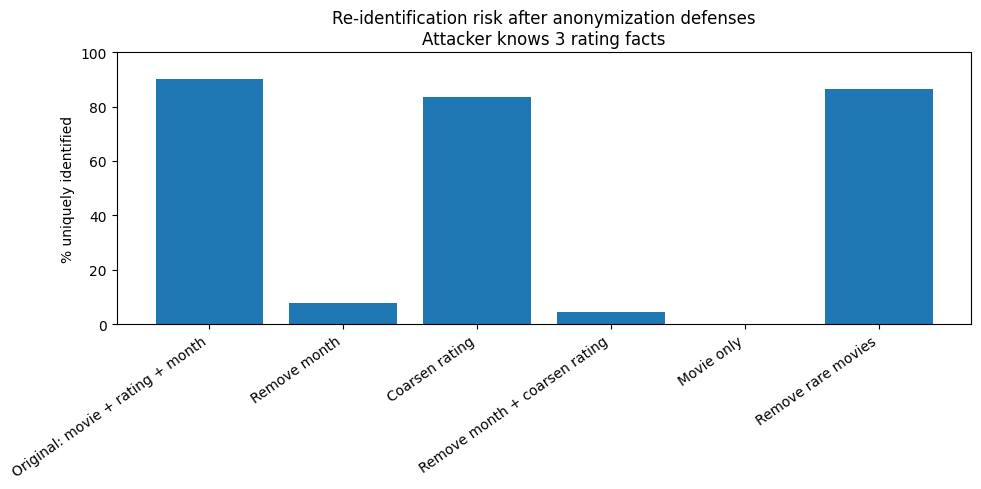

In [45]:
import matplotlib.pyplot as plt

chart_df = plot_df[plot_df["n_known"] == 3].sort_values("release_label")

plt.figure(figsize=(10, 5))
plt.bar(chart_df["release_label"].astype(str), chart_df["pct_unique"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("% uniquely identified")
plt.title("Re-identification risk after anonymization defenses\nAttacker knows 3 rating facts")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [46]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

# Start from your existing df, but remove date/month from the attack data.
# We keep year as an optional weaker time feature.

df_attack = df.copy()

if "date" in df_attack.columns:
    df_attack["date"] = pd.to_datetime(df_attack["date"])
    df_attack["year"] = df_attack["date"].dt.year

# Drop date/month from the actual attack dataframe.
df_attack = df_attack[["user_id", "movie_id", "rating", "year"]].copy()

df_attack["user_id"] = df_attack["user_id"].astype(int)
df_attack["movie_id"] = df_attack["movie_id"].astype(int)
df_attack["rating"] = df_attack["rating"].astype(int)
df_attack["year"] = df_attack["year"].astype(int)

print("ratings:", len(df_attack))
print("users:", df_attack["user_id"].nunique())
print("movies:", df_attack["movie_id"].nunique())
print("years:", sorted(df_attack["year"].unique()))

df_attack.head()

ratings: 1000000
users: 283705
movies: 225
years: [np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005)]


,user_id,movie_id,rating,year
0,1488844,1,3,2005
1,822109,1,5,2005
2,885013,1,4,2005
3,30878,1,4,2005
4,823519,1,3,2004


In [47]:
# Attacker knowledge modes with NO date/month.
# The second one keeps year, which is much weaker than month/date but still temporal.

KNOWLEDGE_MODES_NO_MONTH = {
    "movie_rating_no_time": ["movie_id", "rating"],
    "movie_rating_year": ["movie_id", "rating", "year"],
}


def random_different_values(original_values, pool, rng):
    """
    Replace each value by a random DIFFERENT value from pool.
    """
    original_values = np.asarray(original_values)
    pool = np.asarray(pool)

    if len(pool) <= 1:
        return original_values.copy()

    new_values = rng.choice(pool, size=len(original_values))
    same = new_values == original_values

    while same.any():
        new_values[same] = rng.choice(pool, size=same.sum())
        same = new_values == original_values

    return new_values


def make_noisy_release(
    clean_data,
    rating_p=0.0,
    movie_p=0.0,
    user_p=0.0,
    seed=0
):
    """
    Create a noisy released dataset.

    rating_p: probability that a row's rating is changed to a different rating.
    movie_p: probability that a row's movie_id is changed to a different movie_id.
    user_p: probability that a row's user_id is changed to a different user_id.

    This is row-level noise.
    """
    rng = np.random.default_rng(seed)
    released = clean_data.copy()

    n = len(released)

    # Flip rating with probability rating_p
    if rating_p > 0:
        mask = rng.random(n) < rating_p
        released.loc[mask, "rating"] = random_different_values(
            released.loc[mask, "rating"].to_numpy(),
            pool=[1, 2, 3, 4, 5],
            rng=rng
        )

    # Change movie_id with probability movie_p
    if movie_p > 0:
        mask = rng.random(n) < movie_p
        released.loc[mask, "movie_id"] = random_different_values(
            released.loc[mask, "movie_id"].to_numpy(),
            pool=clean_data["movie_id"].unique(),
            rng=rng
        )

    # Change user_id / pseudonym with probability user_p
    if user_p > 0:
        mask = rng.random(n) < user_p
        released.loc[mask, "user_id"] = random_different_values(
            released.loc[mask, "user_id"].to_numpy(),
            pool=clean_data["user_id"].unique(),
            rng=rng
        )

    return released


def row_key(row, cols):
    values = tuple(row[c] for c in cols)
    return values[0] if len(values) == 1 else values


def build_user_index(data, cols):
    """
    Maps each fact, e.g. (movie_id, rating), to the set of users having that fact.
    """
    small = data[cols + ["user_id"]].drop_duplicates()
    return small.groupby(cols)["user_id"].agg(lambda x: set(x)).to_dict()


def candidate_set_for_rows(known_rows, cols, index):
    """
    Return the set of released users matching all known facts.
    """
    candidates = None

    for _, row in known_rows.iterrows():
        key = row_key(row, cols)
        matching = index.get(key, set())

        if candidates is None:
            candidates = set(matching)
        else:
            candidates &= matching

        if len(candidates) == 0:
            break

    return candidates if candidates is not None else set()

In [48]:
# Histories are sampled from the TRUE clean data.
# The index is built from the NOISY released data.

clean_user_histories = {
    user_id: group
    for user_id, group in df_attack.groupby("user_id")
}

clean_user_counts = df_attack["user_id"].value_counts()


def evaluate_noisy_release(
    clean_data,
    released_data,
    scenario_name,
    p,
    knowledge_name,
    cols,
    n_known_values=[1, 2, 3, 4],
    trials=300,
    candidate_cutoff=5,
    seed=0
):
    """
    candidate_cutoff=5 means we count k < 5, i.e. 1,2,3,4 candidates.

    False positive among k < 5:
    candidate set is nonempty and has size < 5, but target_user is not in it.
    """
    rng = np.random.default_rng(seed)

    index = build_user_index(released_data, cols)

    results = []

    for n_known in n_known_values:
        eligible_users = clean_user_counts[clean_user_counts >= n_known].index.to_numpy()

        for _ in range(trials):
            target_user = int(rng.choice(eligible_users))
            history = clean_user_histories[target_user]

            known_rows = history.sample(
                n_known,
                random_state=int(rng.integers(0, 2**32 - 1))
            )

            candidates = candidate_set_for_rows(known_rows, cols, index)
            candidate_count = len(candidates)

            true_user_in_candidates = target_user in candidates

            less_than_5_candidates = (candidate_count > 0) and (candidate_count < candidate_cutoff)
            less_than_5_correct = less_than_5_candidates and true_user_in_candidates
            less_than_5_wrong = less_than_5_candidates and (not true_user_in_candidates)

            unique = candidate_count == 1
            unique_correct = unique and true_user_in_candidates
            unique_wrong = unique and (not true_user_in_candidates)

            results.append({
                "scenario": scenario_name,
                "p": p,
                "knowledge_name": knowledge_name,
                "knowledge_cols": " + ".join(cols),
                "n_known": n_known,
                "target_user": target_user,
                "candidate_count": candidate_count,

                "true_user_in_candidates": true_user_in_candidates,

                "less_than_5_candidates": less_than_5_candidates,
                "less_than_5_correct": less_than_5_correct,
                "less_than_5_wrong": less_than_5_wrong,

                "unique": unique,
                "unique_correct": unique_correct,
                "unique_wrong": unique_wrong,

                "no_match": candidate_count == 0,
            })

    return pd.DataFrame(results)


def summarize_noisy_results(results):
    summary = results.groupby(
        ["scenario", "p", "knowledge_name", "knowledge_cols", "n_known"]
    ).agg(
        trials=("candidate_count", "size"),

        avg_candidate_size=("candidate_count", "mean"),
        median_candidate_size=("candidate_count", "median"),

        pct_unique=("unique", lambda x: x.mean() * 100),
        pct_unique_correct=("unique_correct", lambda x: x.mean() * 100),
        pct_unique_wrong=("unique_wrong", lambda x: x.mean() * 100),

        pct_less_than_5_candidates=("less_than_5_candidates", lambda x: x.mean() * 100),
        pct_less_than_5_correct=("less_than_5_correct", lambda x: x.mean() * 100),
        pct_less_than_5_wrong=("less_than_5_wrong", lambda x: x.mean() * 100),

        pct_no_match=("no_match", lambda x: x.mean() * 100),

        less_than_5_count=("less_than_5_candidates", "sum"),
        less_than_5_wrong_count=("less_than_5_wrong", "sum"),
        unique_count=("unique", "sum"),
        unique_wrong_count=("unique_wrong", "sum"),
    ).reset_index()

    summary["false_positive_rate_among_less_than_5"] = (
        100 * summary["less_than_5_wrong_count"] / summary["less_than_5_count"].replace(0, np.nan)
    )

    summary["false_positive_rate_among_unique"] = (
        100 * summary["unique_wrong_count"] / summary["unique_count"].replace(0, np.nan)
    )

    summary["false_positive_rate_among_less_than_5"] = summary["false_positive_rate_among_less_than_5"].fillna(0)
    summary["false_positive_rate_among_unique"] = summary["false_positive_rate_among_unique"].fillna(0)

    return summary

In [49]:
# You can increase trials to 500 or 1000 later.
# Start with 200 or 300 so it runs reasonably fast.

p_values = [0.00, 0.01, 0.02, 0.05, 0.10, 0.20]
trials = 300
n_known_values = [1, 2, 3, 4]

noise_scenarios = [
    "rating_noise",
    "movie_noise",
    "user_id_noise",
    "all_three_noise",
]

all_noise_results = []

base_seed = 12345
run_counter = 0

for scenario in noise_scenarios:
    for p in p_values:
        print("Making release:", scenario, "p =", p)

        rating_p = p if scenario in ["rating_noise", "all_three_noise"] else 0.0
        movie_p = p if scenario in ["movie_noise", "all_three_noise"] else 0.0
        user_p = p if scenario in ["user_id_noise", "all_three_noise"] else 0.0

        released_data = make_noisy_release(
            df_attack,
            rating_p=rating_p,
            movie_p=movie_p,
            user_p=user_p,
            seed=base_seed + run_counter
        )

        for knowledge_name, cols in KNOWLEDGE_MODES_NO_MONTH.items():
            print("  Evaluating:", knowledge_name)

            result = evaluate_noisy_release(
                clean_data=df_attack,
                released_data=released_data,
                scenario_name=scenario,
                p=p,
                knowledge_name=knowledge_name,
                cols=cols,
                n_known_values=n_known_values,
                trials=trials,
                candidate_cutoff=5,
                seed=base_seed + 10_000 + run_counter
            )

            all_noise_results.append(result)
            run_counter += 1

all_noise_results = pd.concat(all_noise_results, ignore_index=True)

noise_summary = summarize_noisy_results(all_noise_results)

noise_summary.head(20)

Making release: rating_noise p = 0.0
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: rating_noise p = 0.01
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: rating_noise p = 0.02
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: rating_noise p = 0.05
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: rating_noise p = 0.1
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: rating_noise p = 0.2
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: movie_noise p = 0.0
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: movie_noise p = 0.01
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: movie_noise p = 0.02
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: movie_noise p = 0.05
  Evaluating: movie_ratin

,scenario,p,knowledge_name,knowledge_cols,n_known,trials,avg_candidate_size,median_candidate_size,pct_unique,pct_unique_correct,...,pct_less_than_5_candidates,pct_less_than_5_correct,pct_less_than_5_wrong,pct_no_match,less_than_5_count,less_than_5_wrong_count,unique_count,unique_wrong_count,false_positive_rate_among_less_than_5,false_positive_rate_among_unique
0,all_three_noise,0.00,movie_rating_no_time,movie_id + rating,1,300,18347.623333,13174.5,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000
1,all_three_noise,0.00,movie_rating_no_time,movie_id + rating,2,300,1129.423333,394.5,0.666667,0.666667,...,5.666667,5.666667,0.000000,0.000000,17,0,2,0,0.000000,0.000000
2,all_three_noise,0.00,movie_rating_no_time,movie_id + rating,3,300,126.353333,33.5,11.666667,11.666667,...,22.000000,22.000000,0.000000,0.000000,66,0,35,0,0.000000,0.000000
3,all_three_noise,0.00,movie_rating_no_time,movie_id + rating,4,300,15.960000,3.0,32.000000,32.000000,...,57.666667,57.666667,0.000000,0.000000,173,0,96,0,0.000000,0.000000
4,all_three_noise,0.00,movie_rating_year,movie_id + rating + year,1,300,8910.133333,5683.0,0.000000,0.000000,...,0.333333,0.333333,0.000000,0.000000,1,0,0,0,0.000000,0.000000
5,all_three_noise,0.00,movie_rating_year,movie_id + rating + year,2,300,428.693333,107.0,4.666667,4.666667,...,12.666667,12.666667,0.000000,0.000000,38,0,14,0,0.000000,0.000000
6,all_three_noise,0.00,movie_rating_year,movie_id + rating + year,3,300,26.026667,4.0,29.000000,29.000000,...,53.666667,53.666667,0.000000,0.000000,161,0,87,0,0.000000,0.000000
7,all_three_noise,0.00,movie_rating_year,movie_id + rating + year,4,300,2.910000,1.0,68.666667,68.666667,...,86.666667,86.666667,0.000000,0.000000,260,0,206,0,0.000000,0.000000
8,all_three_noise,0.01,movie_rating_no_time,movie_id + rating,1,300,16290.570000,10449.5,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000
9,all_three_noise,0.01,movie_rating_no_time,movie_id + rating,2,300,1394.836667,562.5,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,3,0,0,0,0.000000,0.000000


In [50]:
# Main table: attacker knows 3 or 4 facts, and we track k < 5.

main_noise_table = noise_summary[
    noise_summary["n_known"].isin([3, 4])
].copy()

main_noise_table = main_noise_table[[
    "scenario",
    "p",
    "knowledge_name",
    "n_known",
    "median_candidate_size",
    "avg_candidate_size",
    "pct_unique",
    "pct_unique_correct",
    "pct_unique_wrong",
    "pct_less_than_5_candidates",
    "pct_less_than_5_correct",
    "pct_less_than_5_wrong",
    "false_positive_rate_among_less_than_5",
    "pct_no_match",
]]

main_noise_table = main_noise_table.sort_values(
    ["knowledge_name", "n_known", "scenario", "p"]
)

main_noise_table.style.format({
    "p": "{:.2f}",
    "median_candidate_size": "{:.1f}",
    "avg_candidate_size": "{:.1f}",
    "pct_unique": "{:.1f}%",
    "pct_unique_correct": "{:.1f}%",
    "pct_unique_wrong": "{:.1f}%",
    "pct_less_than_5_candidates": "{:.1f}%",
    "pct_less_than_5_correct": "{:.1f}%",
    "pct_less_than_5_wrong": "{:.1f}%",
    "false_positive_rate_among_less_than_5": "{:.1f}%",
    "pct_no_match": "{:.1f}%",
})

,scenario,p,knowledge_name,n_known,median_candidate_size,avg_candidate_size,pct_unique,pct_unique_correct,pct_unique_wrong,pct_less_than_5_candidates,pct_less_than_5_correct,pct_less_than_5_wrong,false_positive_rate_among_less_than_5,pct_no_match
2,all_three_noise,0.00,movie_rating_no_time,3,33.5,126.4,11.7%,11.7%,0.0%,22.0%,22.0%,0.0%,0.0%,0.0%
10,all_three_noise,0.01,movie_rating_no_time,3,25.5,106.5,10.3%,10.0%,0.3%,23.0%,21.7%,1.3%,5.8%,1.3%
18,all_three_noise,0.02,movie_rating_no_time,3,31.5,121.1,10.7%,9.7%,1.0%,21.0%,18.7%,2.3%,11.1%,1.3%
26,all_three_noise,0.05,movie_rating_no_time,3,24.5,97.2,8.0%,6.7%,1.3%,20.3%,14.7%,5.7%,27.9%,3.7%
34,all_three_noise,0.10,movie_rating_no_time,3,21.5,72.9,10.7%,7.0%,3.7%,21.7%,13.0%,8.7%,40.0%,6.3%
42,all_three_noise,0.20,movie_rating_no_time,3,9.0,35.9,9.3%,2.0%,7.3%,25.7%,6.7%,19.0%,74.0%,10.7%
50,movie_noise,0.00,movie_rating_no_time,3,25.5,127.5,9.0%,9.0%,0.0%,21.7%,21.7%,0.0%,0.0%,0.0%
58,movie_noise,0.01,movie_rating_no_time,3,35.0,119.9,9.0%,8.3%,0.7%,22.3%,21.7%,0.7%,3.0%,0.0%
66,movie_noise,0.02,movie_rating_no_time,3,38.0,139.0,10.3%,9.7%,0.7%,20.0%,18.0%,2.0%,10.0%,0.7%
74,movie_noise,0.05,movie_rating_no_time,3,28.0,93.0,8.0%,6.7%,1.3%,21.7%,19.3%,2.3%,10.8%,1.3%


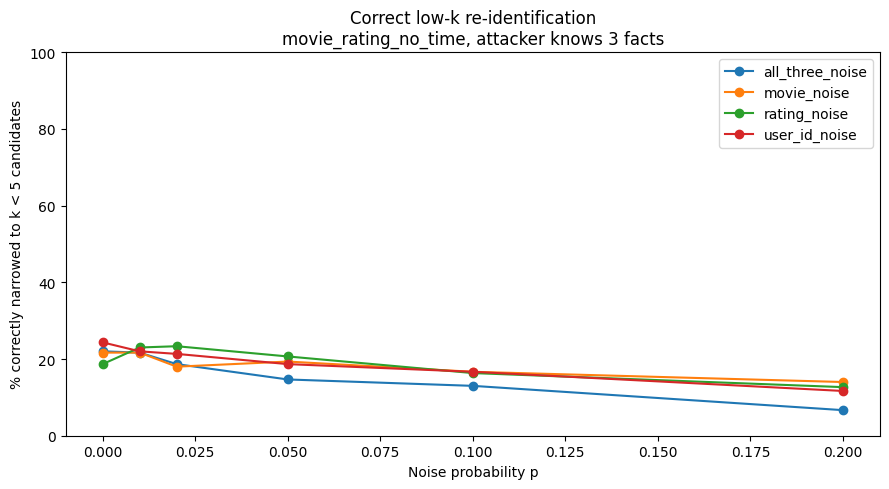

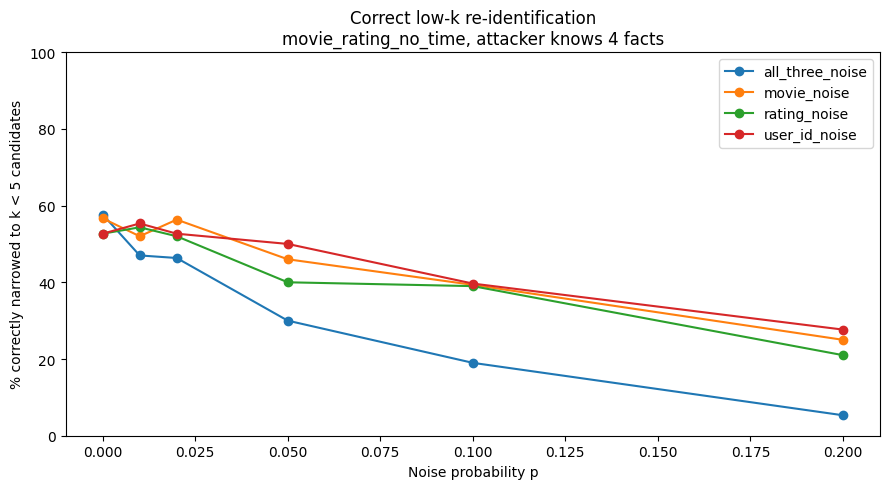

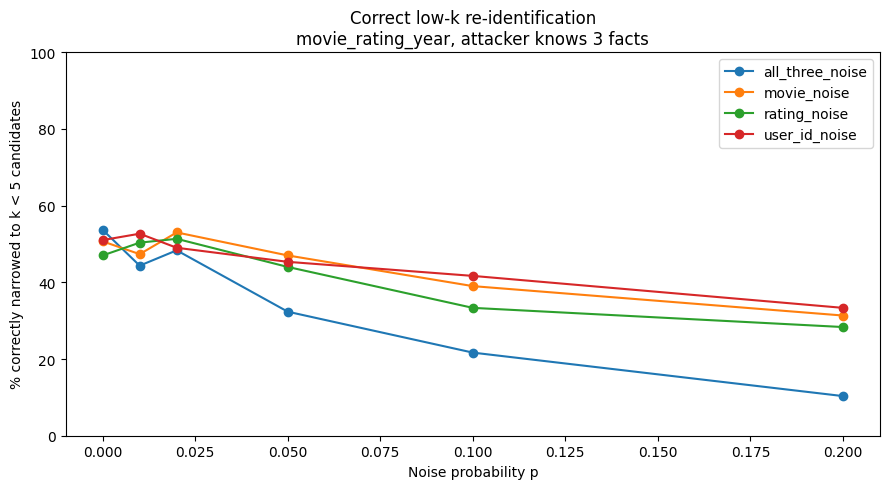

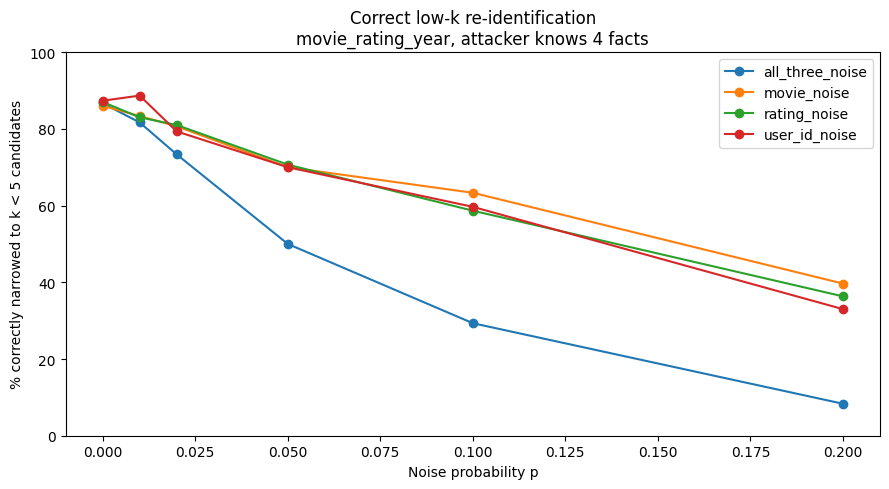

In [52]:
# Plot: percent of trials where the attack returns k < 5 candidates
# AND the true user is actually inside that small candidate set.

for knowledge_name in KNOWLEDGE_MODES_NO_MONTH.keys():
    for n_known in [3, 4]:
        chart_df = noise_summary[
            (noise_summary["knowledge_name"] == knowledge_name)
            & (noise_summary["n_known"] == n_known)
        ].copy()

        plt.figure(figsize=(9, 5))

        for scenario, part in chart_df.groupby("scenario"):
            part = part.sort_values("p")
            plt.plot(
                part["p"],
                part["pct_less_than_5_correct"],
                marker="o",
                label=scenario
            )

        plt.xlabel("Noise probability p")
        plt.ylabel("% correctly narrowed to k < 5 candidates")
        plt.title(f"Correct low-k re-identification\n{knowledge_name}, attacker knows {n_known} facts")
        plt.ylim(0, 100)
        plt.legend()
        plt.tight_layout()
        plt.show()

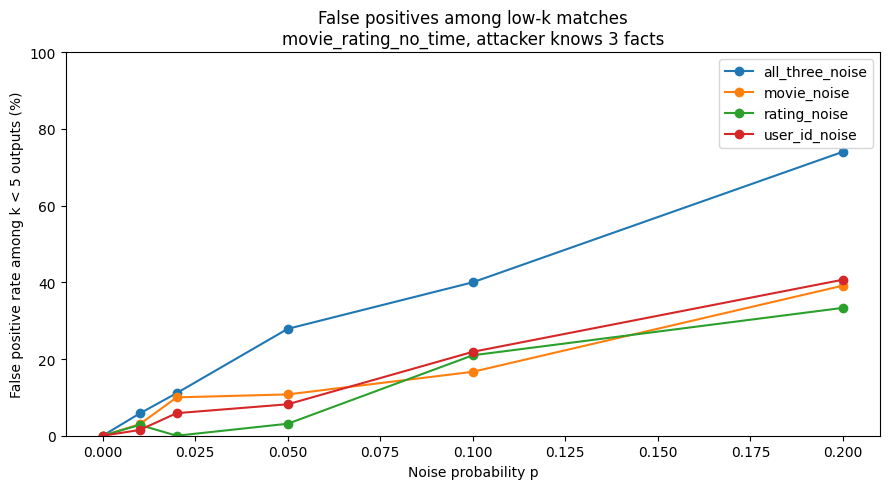

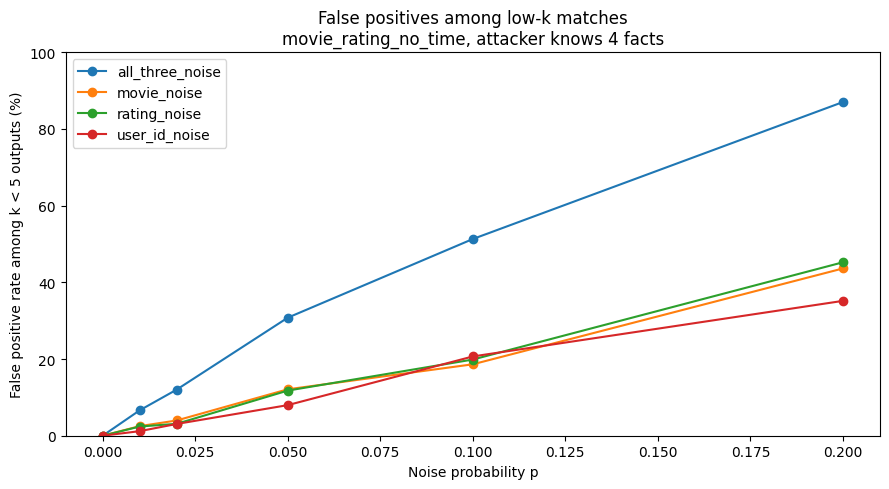

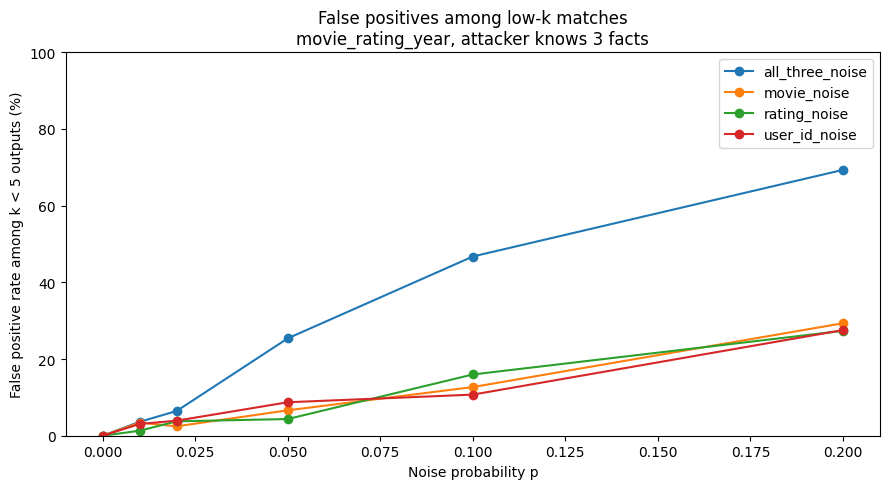

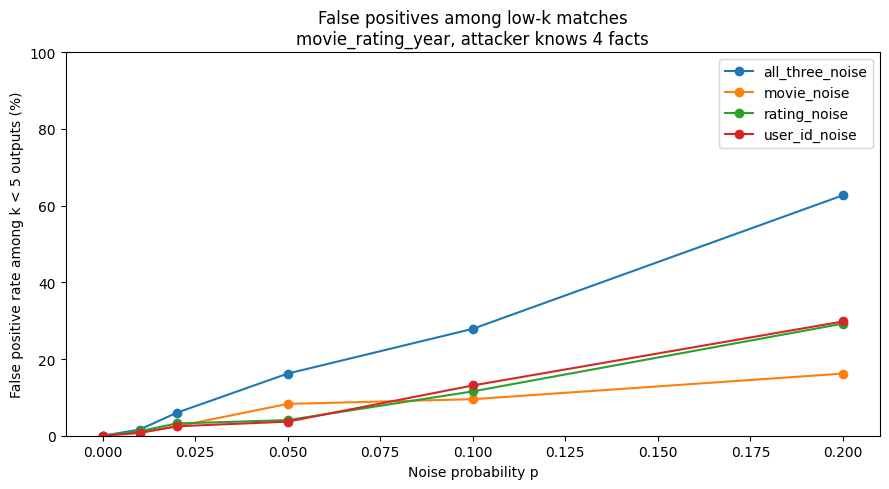

In [53]:
# Plot: among cases where the attack returns k < 5 candidates,
# how often is the true user NOT in that candidate set?

for knowledge_name in KNOWLEDGE_MODES_NO_MONTH.keys():
    for n_known in [3, 4]:
        chart_df = noise_summary[
            (noise_summary["knowledge_name"] == knowledge_name)
            & (noise_summary["n_known"] == n_known)
        ].copy()

        plt.figure(figsize=(9, 5))

        for scenario, part in chart_df.groupby("scenario"):
            part = part.sort_values("p")
            plt.plot(
                part["p"],
                part["false_positive_rate_among_less_than_5"],
                marker="o",
                label=scenario
            )

        plt.xlabel("Noise probability p")
        plt.ylabel("False positive rate among k < 5 outputs (%)")
        plt.title(f"False positives among low-k matches\n{knowledge_name}, attacker knows {n_known} facts")
        plt.ylim(0, 100)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [54]:
all_noise_results.to_csv("noise_attack_raw_results.csv", index=False)
noise_summary.to_csv("noise_attack_summary.csv", index=False)
main_noise_table.to_csv("noise_attack_main_table.csv", index=False)

print("Saved:")
print("noise_attack_raw_results.csv")
print("noise_attack_summary.csv")
print("noise_attack_main_table.csv")

Saved:
noise_attack_raw_results.csv
noise_attack_summary.csv
noise_attack_main_table.csv
